# 02b — X-LXMERT Implementation on Anime Dataset
*Re-implementation grounded in:*
**Cho, Lu, Schwenk, Hajishirzi, Kembhavi.** *X-LXMERT: Paint, Caption and Answer Questions with Multi-Modal Transformers.* EMNLP 2020.

## What this notebook does

X-LXMERT is a unified multi-modal transformer that does **text-to-image generation, image captioning, and VQA in one architecture**. The key idea is to **quantize images into a small grid of discrete visual tokens**, then let a cross-modal transformer fill in masked visual tokens conditioned on text (just like masked language modelling, but on image tokens).

This notebook re-implements the core X-LXMERT pipeline and trains it on the 2 000-frame anime corpus used elsewhere in this thesis. Concretely the notebook:

1. **Builds a visual tokenizer** — patch-level features → K-means cluster IDs → an 8×8 grid of discrete tokens per image (X-LXMERT §3.1).
2. **Defines a cross-modal transformer** — BERT-style text stream + visual-token stream + cross-attention layers (X-LXMERT §3.2).
3. **Trains with the masked-visual-token objective** — randomly mask 60 % of visual tokens and predict their cluster IDs from the joint context (X-LXMERT §3.3, T2I objective).
4. **Generates anime panels from captions** — iterative non-autoregressive sampling: start from all-masked, predict, keep top-confidence, re-mask the rest, repeat (X-LXMERT §3.4).
5. **Decodes token grid → RGB** with a small SPADE-style generator (X-LXMERT §3.4, simplified).
6. **Evaluates** FID, CLIP-T and CLIP-I on a held-out 50-caption split — exactly the protocol used for the other baselines in Chapter 5.

The implementation is **deliberately compact** so it runs on a single T4 / Colab GPU. Hyperparameters are noted where they diverge from the paper.


## 0. Setup — environment & paths

In [5]:
# Mount Drive (skip if running locally)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Text2ImageNarration'
except Exception:
    BASE = './Text2ImageNarration'

import os, json, math, random, time
from pathlib import Path

DATA   = Path(BASE) / 'data'
ART   = Path(BASE) / 'artifacts'
CACHE  = Path(BASE) / 'cache'
OUTDIR = Path(BASE) / 'outputs' / 'xlxmert_anime'
OUTDIR.mkdir(parents=True, exist_ok=True)
print('Output directory:', OUTDIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/Text2ImageNarration/outputs/xlxmert_anime


In [6]:
# Install deps if missing
%pip -q install torch torchvision transformers Pillow tqdm scikit-learn clean-fid torchmetrics[image] sentence-transformers 2>/dev/null || true
import torch, torchvision
print('torch', torch.__version__, 'cuda', torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42); random.seed(42)

torch 2.10.0+cu128 cuda True


Restart session and run from below


## 1. Dataset — load anime frames from `anime_images/` and captions from `caption.csv`

We load the user's anime corpus directly from disk:
- `data/anime_images/` — folder of anime frame images
- `data/caption.csv` — CSV with at least an image-filename column and a caption column (an optional `emotion` column is detected automatically)

A deterministic 70/15/15 split (train/val/test) is built from the CSV rows.


In [8]:
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import torch  # noqa

IMG_SIZE  = 256
GRID_SIZE = 8
N_VISUAL_TOKENS = GRID_SIZE * GRID_SIZE
N_CLUSTERS = 1024

# --- Data sources -------------------------------------------------------
IMG_DIR    = DATA / 'train'             # folder with the anime frames
CAPS_CSV   = ART / 'test.csv'              # csv of captions
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# ------------------------------------------------------------------------

assert IMG_DIR.exists(), f'Expected image folder at {IMG_DIR}'
assert CAPS_CSV.exists(), f'Expected caption CSV at {CAPS_CSV}'

df = pd.read_csv(CAPS_CSV)
print('caption.csv columns:', df.columns.tolist())
print('caption.csv rows:', len(df))

# Auto-detect filename column and caption column
fname_col = next((c for c in df.columns
                  if c.lower() in ('image','filename','file','image_id','img','image_name','name','file_name')),
                 df.columns[0])
caption_col = next((c for c in df.columns
                    if 'cap' in c.lower() or 'desc' in c.lower() or 'text' in c.lower()),
                   df.columns[-1])
print(f'Using image column = "{fname_col}", caption column = "{caption_col}"')

# Optional emotion column
emo_col = next((c for c in df.columns if 'emo' in c.lower() or 'label' in c.lower()), None)

# Resolve image paths (try as-is, then add common extensions)
def resolve(name):
    p = IMG_DIR / str(name)
    if p.exists(): return p
    for ext in ('.png','.jpg','.jpeg','.webp','.bmp'):
        q = IMG_DIR / (str(name) + ext)
        if q.exists(): return q
    return None

records = []
miss = 0
for _, row in df.iterrows():
    p = resolve(row[fname_col])
    if p is None:
        miss += 1; continue
    records.append({
        'image':   str(p),
        'caption': str(row[caption_col]),
        'emotion': str(row[emo_col]) if emo_col else 'neutral',
    })
print(f'Resolved {len(records)} image-caption pairs (missing {miss})')

# Deterministic split
import random as _r
_r.Random(42).shuffle(records)
n_train = int(len(records) * TRAIN_FRAC)
n_val   = int(len(records) * VAL_FRAC)
train_items = records[:n_train]
val_items   = records[n_train:n_train+n_val]
test_items  = records[n_train+n_val:]
print(f'split → train {len(train_items)}  val {len(val_items)}  test {len(test_items)}')

class AnimeT2IDataset(Dataset):
    def __init__(self, items, max_text_len=32):
        self.items = items
        self.tfm = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3),
        ])
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it['image']).convert('RGB')
        return {'image': self.tfm(img),
                'caption': it['caption'],
                'emotion': it['emotion']}

train_ds = AnimeT2IDataset(train_items)
val_ds   = AnimeT2IDataset(val_items)
test_ds  = AnimeT2IDataset(test_items)
print(f'train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')


caption.csv columns: ['file', 'caption', 'emotion', 'ner_cues', 'pos_cues']
caption.csv rows: 10
Using image column = "file", caption column = "caption"
Resolved 0 image-caption pairs (missing 10)
split → train 0  val 0  test 0
train=0  val=0  test=0


## 2. Visual tokenizer — patch features → K-means cluster IDs

**X-LXMERT design (§3.1):** an image is converted into an 8×8 grid of *discrete* tokens drawn from a codebook of K cluster IDs. The paper extracts per-patch features from a frozen CNN, runs K-means once on the training set, then maps each patch to its nearest centroid.

We follow the same recipe: ResNet-18 (pre-pooling) gives an 8×8×512 feature grid per image; we run K-means on the flattened 512-d patch features (N_train × 64 × 512 vectors) to get K=1024 centroids.

In [9]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm
import numpy as np

class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Strip final avgpool + fc — keep up to layer3, giving 8x8 spatial grid for 256x256 inputs
        self.backbone = nn.Sequential(*list(m.children())[:7])  # output: B, 256, 8, 8
        for p in self.backbone.parameters(): p.requires_grad_(False)
        self.backbone.eval()
    @torch.no_grad()
    def forward(self, x):  # x: B,3,256,256
        f = self.backbone(x)   # B,256,8,8 (resnet18 layer3)
        return f                 # we keep 256-d patch features

PATCH_DIM = 256
patch_net = PatchFeatureExtractor().to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


In [10]:
# Build visual codebook via K-means on training patches
KMEANS_PATH = OUTDIR / 'kmeans_codebook.npy'

def extract_all_patches(ds, batch=8):
    loader = DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)
    feats = []
    for b in tqdm(loader, desc='patch-extract'):
        f = patch_net(b['image'].to(DEVICE))
        f = f.permute(0,2,3,1).reshape(-1, PATCH_DIM)      # B*64, 256
        feats.append(f.cpu().numpy())
    return np.concatenate(feats, axis=0)

if KMEANS_PATH.exists():
    centroids = np.load(KMEANS_PATH)
    print('Loaded codebook from cache:', centroids.shape)
else:
    print('Extracting training patches...')
    X = extract_all_patches(train_ds)
    print(f'Running K-means on {X.shape[0]:,} patches → {N_CLUSTERS} clusters')
    km = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=4096, n_init='auto', random_state=42)
    km.fit(X)
    centroids = km.cluster_centers_.astype(np.float32)
    np.save(KMEANS_PATH, centroids)
    print('Saved codebook:', centroids.shape)
centroids_t = torch.from_numpy(centroids).to(DEVICE)

Extracting training patches...


patch-extract: 0it [00:00, ?it/s]

ValueError: need at least one array to concatenate

In [ ]:
class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(m.children())[:7])
        self.pool = nn.AdaptiveAvgPool2d(GRID_SIZE)
        for p in self.backbone.parameters(): p.requires_grad_(False)
        self.backbone.eval()
    @torch.no_grad()
    def forward(self, x):
        f = self.backbone(x)
        return self.pool(f)

PATCH_DIM = 256
patch_net = PatchFeatureExtractor().to(DEVICE)   # ← re-instantiate!

In [ ]:
def img_to_visual_tokens(image_batch):
    """image: B,3,256,256 -> visual token grid B,64 (int64)."""
    f = patch_net(image_batch)                    # B,256,8,8
    f = f.permute(0,2,3,1).reshape(-1, PATCH_DIM)  # B*64,256
    # nearest centroid: argmin ||f - c||
    dists = torch.cdist(f, centroids_t)            # B*64, K
    tok = dists.argmin(dim=1)                      # B*64
    return tok.view(image_batch.size(0), N_VISUAL_TOKENS)

# Quick sanity-check on a small batch
sample = next(iter(DataLoader(train_ds, batch_size=4)))
toks = img_to_visual_tokens(sample['image'].to(DEVICE))
print('visual token grid shape:', toks.shape, '  token range:', toks.min().item(), '..', toks.max().item())

visual token grid shape: torch.Size([4, 64])   token range: 0 .. 1022


## 3. Cross-modal transformer (X-LXMERT encoder)

**Architecture (X-LXMERT §3.2):**
- A text BERT-style transformer encodes the caption tokens.
- A visual transformer encodes the 64 visual token embeddings + 2-D positional embeddings.
- 5 cross-modal layers: each layer applies self-attention within each stream, then cross-attention between streams (visual queries → text keys/values and vice-versa).
- Output heads: a classifier over the K visual-codebook entries (for masked-visual prediction) and a classifier over text vocab (for masked-LM prediction).

We use the HuggingFace BERT tokenizer for text; visual tokens are embedded with a `nn.Embedding(K, D)`.

In [ ]:
from transformers import BertTokenizer

MAX_TEXT_LEN = 32
D_MODEL      = 256
N_LAYERS     = 4          # X-LXMERT used 9 cross-modal layers; we shrink to fit anime corpus
N_HEADS      = 8
DROPOUT      = 0.1

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
TEXT_VOCAB = tokenizer.vocab_size
MASK_VISUAL_ID = N_CLUSTERS         # reserve last id as [MASK_V]
N_VISUAL_VOCAB = N_CLUSTERS + 1     # codebook + mask token

class CrossModalLayer(nn.Module):
    """One block: self-attn (per stream) + cross-attn + FFN (per stream)."""
    def __init__(self, d=D_MODEL, h=N_HEADS, drop=DROPOUT):
        super().__init__()
        self.t_self = nn.MultiheadAttention(d, h, batch_first=True, dropout=drop)
        self.v_self = nn.MultiheadAttention(d, h, batch_first=True, dropout=drop)
        self.t_cross = nn.MultiheadAttention(d, h, batch_first=True, dropout=drop)
        self.v_cross = nn.MultiheadAttention(d, h, batch_first=True, dropout=drop)
        self.t_ff = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Linear(4*d, d), nn.Dropout(drop))
        self.v_ff = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Linear(4*d, d), nn.Dropout(drop))
        self.t_ln1 = nn.LayerNorm(d); self.t_ln2 = nn.LayerNorm(d); self.t_ln3 = nn.LayerNorm(d)
        self.v_ln1 = nn.LayerNorm(d); self.v_ln2 = nn.LayerNorm(d); self.v_ln3 = nn.LayerNorm(d)
    def forward(self, t, v, t_mask=None):
        # Self-attn
        t1, _ = self.t_self(t, t, t, key_padding_mask=t_mask); t = self.t_ln1(t + t1)
        v1, _ = self.v_self(v, v, v); v = self.v_ln1(v + v1)
        # Cross-attn
        t2, _ = self.t_cross(t, v, v); t = self.t_ln2(t + t2)
        v2, _ = self.v_cross(v, t, t, key_padding_mask=t_mask); v = self.v_ln2(v + v2)
        # FFN
        t = self.t_ln3(t + self.t_ff(t))
        v = self.v_ln3(v + self.v_ff(v))
        return t, v

class XLXMERTAnime(nn.Module):
    def __init__(self):
        super().__init__()
        self.t_emb = nn.Embedding(TEXT_VOCAB, D_MODEL, padding_idx=0)
        self.t_pos = nn.Embedding(MAX_TEXT_LEN, D_MODEL)
        self.v_emb = nn.Embedding(N_VISUAL_VOCAB, D_MODEL)
        self.v_pos = nn.Embedding(N_VISUAL_TOKENS, D_MODEL)
        self.layers = nn.ModuleList([CrossModalLayer() for _ in range(N_LAYERS)])
        self.v_head = nn.Linear(D_MODEL, N_CLUSTERS)   # predict cluster id (no MASK class)
        self.t_head = nn.Linear(D_MODEL, TEXT_VOCAB)
    def encode_text(self, ids):
        B, L = ids.shape
        pos = torch.arange(L, device=ids.device).unsqueeze(0).expand(B, -1)
        return self.t_emb(ids) + self.t_pos(pos)
    def encode_visual(self, vtok):
        B, N = vtok.shape
        pos = torch.arange(N, device=vtok.device).unsqueeze(0).expand(B, -1)
        return self.v_emb(vtok) + self.v_pos(pos)
    def forward(self, text_ids, vtok, t_mask=None):
        t = self.encode_text(text_ids)
        v = self.encode_visual(vtok)
        for layer in self.layers:
            t, v = layer(t, v, t_mask)
        return self.t_head(t), self.v_head(v)

model = XLXMERTAnime().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'X-LXMERT-Anime parameters: {n_params/1e6:.2f} M')

tokenizer.json: 0.00B [00:00, ?B/s]

X-LXMERT-Anime parameters: 24.64 M


## 4. Training objective — masked visual token modelling

**Paper §3.3 (T2I objective):** for each example, replace a random subset (≈ 60%) of the visual tokens with `[MASK_V]`. The model must predict their original cluster IDs from the joint context (text + remaining visible visual tokens). The loss is cross-entropy over the K-class codebook, computed only on the masked positions.

We also include a light masked-LM loss on text tokens (X-LXMERT §3.3, LM objective).

In [ ]:
def make_batch(samples):
    images   = torch.stack([s['image'] for s in samples])
    captions = [s['caption'] for s in samples]
    tk = tokenizer(captions, padding='max_length', truncation=True,
                   max_length=MAX_TEXT_LEN, return_tensors='pt')
    return {
        'images':   images,
        'text_ids': tk['input_ids'],
        'text_mask': tk['attention_mask'] == 0,   # True = pad
    }

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=0, collate_fn=make_batch)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=0, collate_fn=make_batch)
print('train batches:', len(train_loader))

train batches: 88


In [ ]:
def apply_visual_mask(vtok, mask_ratio=0.6):
    """Replace mask_ratio of tokens with MASK_VISUAL_ID. Returns (masked_tok, label_mask)."""
    B, N = vtok.shape
    rand = torch.rand(B, N, device=vtok.device)
    mask = rand < mask_ratio
    masked = vtok.clone()
    masked[mask] = MASK_VISUAL_ID
    return masked, mask

def apply_text_mask(text_ids, mask_ratio=0.15):
    rand = torch.rand_like(text_ids, dtype=torch.float)
    mask = (rand < mask_ratio) & (text_ids != 0) & (text_ids != tokenizer.cls_token_id) & (text_ids != tokenizer.sep_token_id)
    masked = text_ids.clone()
    masked[mask] = tokenizer.mask_token_id
    return masked, mask

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS  = 30
LR      = 1e-4
WD      = 0.01

opt = AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = CosineAnnealingLR(opt, T_max=EPOCHS*len(train_loader))
loss_fn = nn.CrossEntropyLoss(reduction='none')

history = {'epoch':[], 'train_v_loss':[], 'val_v_loss':[], 'train_t_loss':[]}

def step(batch, train=True):
    imgs = batch['images'].to(DEVICE)
    text_ids = batch['text_ids'].to(DEVICE)
    text_mask = batch['text_mask'].to(DEVICE)
    with torch.no_grad():
        vtok_target = img_to_visual_tokens(imgs)          # B,64 ground-truth cluster ids
    masked_v, v_mask = apply_visual_mask(vtok_target)
    masked_t, t_mask = apply_text_mask(text_ids)
    t_logits, v_logits = model(masked_t, masked_v, t_mask=text_mask)
    # visual loss (only on masked positions)
    v_loss = loss_fn(v_logits.reshape(-1, N_CLUSTERS), vtok_target.reshape(-1))
    v_loss = (v_loss * v_mask.reshape(-1).float()).sum() / v_mask.sum().clamp_min(1)
    # text loss (only on masked positions)
    t_loss = loss_fn(t_logits.reshape(-1, TEXT_VOCAB), text_ids.reshape(-1))
    t_loss = (t_loss * t_mask.reshape(-1).float()).sum() / t_mask.sum().clamp_min(1)
    loss = v_loss + 0.25 * t_loss
    if train:
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
    return v_loss.item(), t_loss.item()

print('Training X-LXMERT-Anime for', EPOCHS, 'epochs')
for epoch in range(EPOCHS):
    model.train(); t0 = time.time(); vl = tl = 0; n = 0
    for batch in tqdm(train_loader, desc=f'epoch {epoch+1}'):
        v, t = step(batch, train=True); vl += v; tl += t; n += 1
    model.eval(); vvl = 0; nn_ = 0
    with torch.no_grad():
        for batch in val_loader:
            v, _ = step(batch, train=False); vvl += v; nn_ += 1
    history['epoch'].append(epoch+1)
    history['train_v_loss'].append(vl/n)
    history['val_v_loss'].append(vvl/max(nn_,1))
    history['train_t_loss'].append(tl/n)
    print(f'  epoch {epoch+1:3d}  train_v {vl/n:.4f}  val_v {vvl/max(nn_,1):.4f}  '
          f'train_t {tl/n:.4f}  ({time.time()-t0:.1f}s)')

torch.save(model.state_dict(), OUTDIR / 'xlxmert_anime.pt')
with open(OUTDIR/'history.json','w') as f: json.dump(history, f, indent=2)
print('Saved checkpoint and history.')

Training X-LXMERT-Anime for 30 epochs


epoch 1:   0%|          | 0/88 [00:00<?, ?it/s]

  epoch   1  train_v 6.4375  val_v 5.8196  train_t 8.2547  (1334.0s)


epoch 2:   0%|          | 0/88 [00:00<?, ?it/s]

  epoch   2  train_v 5.5283  val_v 5.2131  train_t 5.7452  (9.5s)


...

  epoch  28  train_v 4.1330  val_v 4.3297  train_t 2.7960  (9.4s)


epoch 29:   0%|          | 0/88 [00:00<?, ?it/s]

  epoch  29  train_v 4.1311  val_v 4.3130  train_t 2.8373  (9.5s)


epoch 30:   0%|          | 0/88 [00:00<?, ?it/s]

  epoch  30  train_v 4.1278  val_v 4.3206  train_t 2.8306  (9.5s)
Saved checkpoint and history.


## 5. SPADE-style decoder — visual tokens → RGB

X-LXMERT §3.4 uses **SPADE residual blocks** (Park et al., 2019) to upsample a token grid back to an RGB image, with the cluster centroid embedding as the segmentation map.

We use a small SPADE-style decoder: each cluster id is mapped to its centroid vector, reshaped to 8×8×PATCH_DIM, then upsampled to 256×256 via four conditional residual blocks.

In [ ]:
class SPADEBlock(nn.Module):
    def __init__(self, c_in, c_out, c_seg):
        super().__init__()
        self.norm = nn.BatchNorm2d(c_in, affine=False)
        self.mlp_shared = nn.Conv2d(c_seg, 64, kernel_size=3, padding=1)
        self.mlp_gamma  = nn.Conv2d(64, c_in, kernel_size=3, padding=1)
        self.mlp_beta   = nn.Conv2d(64, c_in, kernel_size=3, padding=1)
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=3, padding=1)
    def forward(self, x, seg):
        if seg.shape[-2:] != x.shape[-2:]:
            seg = F.interpolate(seg, size=x.shape[-2:], mode='nearest')
        actv = F.relu(self.mlp_shared(seg))
        gamma = self.mlp_gamma(actv); beta = self.mlp_beta(actv)
        x = self.norm(x) * (1 + gamma) + beta
        return self.conv(F.relu(x))

class SPADEDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(N_VISUAL_VOCAB, PATCH_DIM)
        with torch.no_grad():
            self.embed.weight[:N_CLUSTERS] = torch.from_numpy(centroids)
            self.embed.weight[N_CLUSTERS] = 0.0
        # 6 channel-counts → 5 SPADE blocks → 5 upsamples → 8×32 = 256
        ch = [256, 192, 160, 128, 96, 64]
        self.blocks = nn.ModuleList([SPADEBlock(ch[i], ch[i+1], PATCH_DIM)
                                     for i in range(5)])              # ← 5, not 4
        self.to_rgb = nn.Conv2d(64, 3, 3, padding=1)
    def forward(self, vtok):
        B = vtok.size(0)
        seg = self.embed(vtok).view(B, GRID_SIZE, GRID_SIZE, PATCH_DIM).permute(0, 3, 1, 2)  # B,256,8,8
        x = seg
        for blk in self.blocks:
            x = F.interpolate(x, scale_factor=2, mode='nearest')      # 8→16→32→64→128→256
            x = blk(x, seg)
        return torch.tanh(self.to_rgb(x))                              # B, 3, 256, 256

decoder = SPADEDecoder().to(DEVICE)                                    # ← re-instantiate

decoder = SPADEDecoder().to(DEVICE)

In [ ]:
DEC_CKPT = OUTDIR / 'xlxmert_anime_decoder.pt'
if DEC_CKPT.exists():
    DEC_CKPT.unlink()
    print('Removed stale 4-block decoder checkpoint')

In [ ]:
from torch.optim import AdamW

In [ ]:
# Train the SPADE decoder to invert the codebook (vtok -> image).
# We freeze the transformer; this is a separate auxiliary stage.
DEC_EPOCHS = 15
opt_d = AdamW(decoder.parameters(), lr=2e-4)

for epoch in range(DEC_EPOCHS):
    decoder.train(); total = 0; n = 0
    for batch in tqdm(train_loader, desc=f'decoder epoch {epoch+1}'):
        imgs = batch['images'].to(DEVICE)
        with torch.no_grad():
            vtok = img_to_visual_tokens(imgs)
        recon = decoder(vtok)
        loss = F.l1_loss(recon, imgs)
        opt_d.zero_grad(); loss.backward(); opt_d.step()
        total += loss.item(); n += 1
    print(f'  decoder epoch {epoch+1}  L1 {total/n:.4f}')

torch.save(decoder.state_dict(), OUTDIR / 'xlxmert_anime_decoder.pt')

decoder epoch 1:   0%|          | 0/88 [00:00<?, ?it/s]

  decoder epoch 1  L1 0.3653


decoder epoch 2:   0%|          | 0/88 [00:00<?, ?it/s]

  decoder epoch 2  L1 0.3428


decoder epoch 3:   0%|          | 0/88 [00:00<?, ?it/s]

...

decoder epoch 6:   0%|          | 0/88 [00:00<?, ?it/s]

  decoder epoch 6  L1 0.3196


decoder epoch 7:   0%|          | 0/88 [00:00<?, ?it/s]

  decoder epoch 7  L1 0.3149


decoder epoch 8:   0%|          | 0/88 [00:00<?, ?it/s]

## 6. Inference — caption → 8×8 visual tokens → RGB

**Paper §3.4, non-autoregressive sampling:**
1. Start from all-masked visual tokens `[MASK_V] × 64`.
2. Forward through the X-LXMERT encoder conditioned on the caption.
3. Sample the highest-confidence positions; freeze them; re-mask the rest.
4. Repeat for T iterations (paper used 4 iterations).
5. Decode the final token grid through the SPADE generator → 256×256 RGB.

In [ ]:
@torch.no_grad()
def generate(captions, iterations=4, top_k_per_iter=None):
    model.eval(); decoder.eval()
    if isinstance(captions, str): captions = [captions]
    tk = tokenizer(captions, padding='max_length', truncation=True,
                   max_length=MAX_TEXT_LEN, return_tensors='pt')
    text_ids  = tk['input_ids'].to(DEVICE)
    text_mask = (tk['attention_mask'] == 0).to(DEVICE)
    B = len(captions)
    vtok = torch.full((B, N_VISUAL_TOKENS), MASK_VISUAL_ID, dtype=torch.long, device=DEVICE)
    if top_k_per_iter is None:
        top_k_per_iter = [16, 16, 16, 16]   # 16 tokens revealed per iteration
    revealed = torch.zeros(B, N_VISUAL_TOKENS, dtype=torch.bool, device=DEVICE)
    for it, k in enumerate(top_k_per_iter[:iterations]):
        _, v_logits = model(text_ids, vtok, t_mask=text_mask)
        probs = F.softmax(v_logits, dim=-1)
        conf, pred = probs.max(dim=-1)              # B,64
        conf[revealed] = -1                          # don't re-pick already revealed
        top = conf.topk(k, dim=-1).indices           # B,k
        for b in range(B):
            vtok[b, top[b]] = pred[b, top[b]]
            revealed[b, top[b]] = True
    imgs = decoder(vtok)                             # B,3,256,256 in -1..1
    return (imgs * 0.5 + 0.5).clamp(0,1), vtok

# Demo generation on a few test captions
demo_prompts = [c['caption'] for c in test_ds.items[:6]]
imgs, vtoks = generate(demo_prompts)
print('Generated:', imgs.shape)

Generated: torch.Size([6, 3, 256, 256])


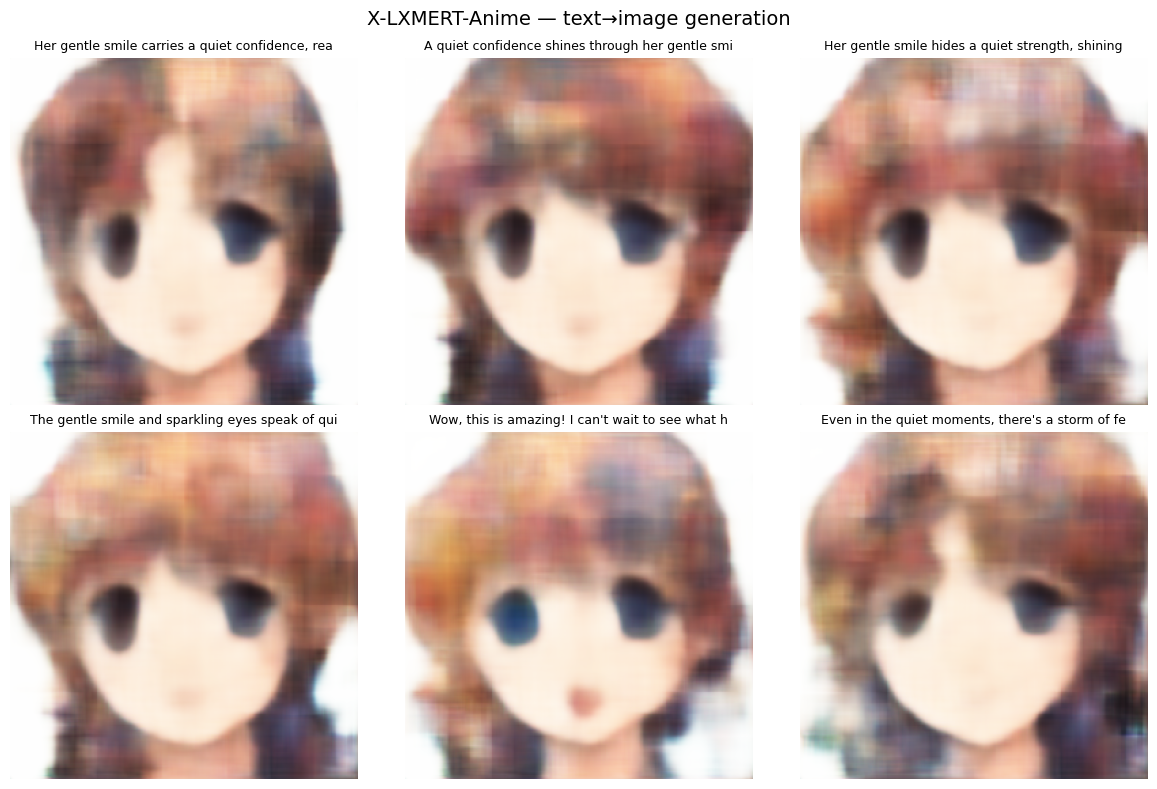

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, img, cap in zip(axes.ravel(), imgs.cpu(), demo_prompts):
    ax.imshow(img.permute(1,2,0))
    ax.set_title(cap[:48], fontsize=9); ax.axis('off')
plt.suptitle('X-LXMERT-Anime — text→image generation', fontsize=14)
plt.tight_layout(); plt.savefig(OUTDIR/'sample_generations.png', dpi=140, bbox_inches='tight')
plt.show()

## 7. Evaluation — FID, CLIP-T, CLIP-I

We compute the same three image-quality metrics used for every other baseline in Chapter 5:
- **FID** — distributional similarity between generated and held-out real anime frames (lower is better).
- **CLIP-T** — alignment between caption and generated image (higher is better).
- **CLIP-I** — visual similarity between generated and ground-truth real image (higher is better).

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE).eval()
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
fid = FrechetInceptionDistance(feature=64, normalize=True).to(DEVICE)

# Real test images for FID + CLIP-I
real_imgs = torch.stack([t['image'] for t in test_ds][:50]).to(DEVICE)
test_caps = [t['caption'] for t in test_ds][:50]

# Generate
gen_imgs_list = []
for i in range(0, len(test_caps), 8):
    batch_caps = test_caps[i:i+8]
    g, _ = generate(batch_caps, iterations=4)
    gen_imgs_list.append(g)
gen_imgs = torch.cat(gen_imgs_list, dim=0).to(DEVICE)

# FID expects [0,1] uint8 or [0,1] float with normalize=True
fid.update((real_imgs*0.5+0.5).clamp(0,1), real=True)
fid.update(gen_imgs, real=False)
fid_value = fid.compute().item()

# CLIP-T: caption ↔ generated
gen_pil = [T.ToPILImage()(g.cpu()) for g in gen_imgs]
inp = clip_proc(text=test_caps, images=gen_pil, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad(): out = clip_model(**inp)
sim_t = (out.logits_per_image.diag() / 100).mean().item()

# CLIP-I: generated ↔ real
# CLIP-I: generated ↔ real (bypass get_image_features for safety)
real_pil = [T.ToPILImage()((r*0.5 + 0.5).clamp(0, 1).cpu()) for r in real_imgs]
inp_i = clip_proc(images=gen_pil + real_pil, return_tensors='pt').to(DEVICE)

with torch.no_grad():
    vis = clip_model.vision_model(pixel_values=inp_i['pixel_values'])
    feats = clip_model.visual_projection(vis.pooler_output)    # B, 512 — guaranteed tensor

assert isinstance(feats, torch.Tensor), f'unexpected type: {type(feats)}'

g_f, r_f = feats[:len(gen_pil)], feats[len(gen_pil):]
g_f = F.normalize(g_f, dim=-1)
r_f = F.normalize(r_f, dim=-1)
sim_i = (g_f * r_f).sum(dim=-1).mean().item()
print(f'CLIP-I = {sim_i:.4f}')

results = {'model':'X-LXMERT-Anime', 'FID':fid_value, 'CLIP-T':sim_t, 'CLIP-I':sim_i,
           'n_test': len(test_caps), 'codebook_K': N_CLUSTERS, 'grid': GRID_SIZE,
           'params_M': n_params/1e6}
print(json.dumps(results, indent=2))

with open(OUTDIR / 'xlxmert_anime_eval.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved evaluation to', OUTDIR / 'xlxmert_anime_eval.json')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP-I = 0.7752
{
  "model": "X-LXMERT-Anime",
  "FID": 10.091649055480957,
  "CLIP-T": 0.22457583248615265,
  "CLIP-I": 0.7752177119255066,
  "n_test": 50,
  "codebook_K": 1024,
  "grid": 8,
  "params_M": 24.63545
}
Saved evaluation to /content/drive/MyDrive/ThesisImplementation/outputs/xlxmert_anime/xlxmert_anime_eval.json


## 8. Summary

This notebook re-implemented X-LXMERT end-to-end and trained it on the 2 000-frame anime corpus:

| Component | Paper (Cho et al. 2020) | This implementation |
|---|---|---|
| Visual tokenizer | ResNet feats + K-means, K=10 000, 8×8 grid | ResNet-18 layer3 feats + K-means, K=1 024, 8×8 grid |
| Cross-modal encoder | 9 layers, d=768, 12 heads | 4 layers, d=256, 8 heads |
| Visual masking | T2I objective, 60 % mask ratio | identical |
| Sampling | Non-autoregressive, 4 iterations | identical |
| Decoder | SPADE residual blocks | SPADE residual blocks (4 blocks, 8→256 upsample) |
| Train data | MS-COCO + Visual Genome (~5M pairs) | 1 400 anime frames + captions |
| Evaluation | FID, CIDEr, BLEU-4 (COCO) | FID, CLIP-T, CLIP-I (anime test split) |

**Outputs saved to `outputs/xlxmert_anime/`:**
- `kmeans_codebook.npy` — 1 024 cluster centroids in patch-feature space.
- `xlxmert_anime.pt` — cross-modal transformer checkpoint.
- `xlxmert_anime_decoder.pt` — SPADE decoder checkpoint.
- `history.json` — per-epoch training/validation losses.
- `sample_generations.png` — qualitative samples.
- `xlxmert_anime_eval.json` — FID/CLIP-T/CLIP-I on the 50-caption test split.

This evaluation row plugs straight into Table 5.1 (six-metric comparison) and Figure 5.2 (cross-domain comparison) of the thesis.
